# Evolutionary Factor Researcher — a step-by-step walkthrough

This notebook opens up the **GraphRAG + FunSearch/AlphaEvolve-style evolutionary
factor researcher** and runs each moving part on its own, so you can see exactly
*what happens in every step* — with numbers you can poke at, not just prose.

The whole system is anchored in `docs/research-evolution/DESIGN.md`. Its single
governing principle:

> **The LLM ideates and mutates; a deterministic harness scores. The LLM must
> never be able to influence its own reward.**

That splits every feedback signal into **two architecturally separate channels**:

| | **Selection fitness** (the *reward*) | **Diagnostic feedback** (the *teacher*) |
| --- | --- | --- |
| Consumer | the deterministic controller | the LLM, when mutating a parent |
| Form | numbers (Pareto vector) + gate booleans | rich natural language + numbers |
| Must be | deterministic, un-gameable, OOS | verbose, specific, even speculative |

Everything below is organised around that split.

### The pipeline, one generation

```
Prompter/Retriever ─▶ Hypothesis ─▶ [Debate] ─▶ Codegen ─▶ Eval harness ─▶ Evolution
 (RAG + GraphRAG)     (mechanism,   (skeptic/   (DSL,      (DETERMINISTIC     controller
                      expected_sign) moderator)  in-mem)    Pareto vector +    (NSGA-II Pareto
                                        ▲                   gates + diags)     archive, islands,
                                        │                        │            N_trials, lineage)
              Reflection (numbers → NL mutation brief) ◀─────────┴────────────────┘
```

### How this notebook is laid out

| § | Component | Source module | Needs |
| --- | --- | --- | --- |
| 1 | Overfitting-control foundation (splits, CPCV, deflation, PBO) | `research_eval/splits.py`, `deflation.py` | offline |
| 2 | The **fitness function** (the reward channel) | `research_eval/harness.py`, `fitness.py` | offline |
| 3 | Genome + mutation operators (jitter, LLM prompts) | `evolution/genome.py`, `mutation.py` | offline |
| 4 | Reflection (the teacher channel) | `evolution/reflection.py` | offline |
| 5 | The NSGA-II evolution controller | `evolution/controller.py` | offline |
| 6 | RAG retrieval | `knowledge/embed_store.py`, `retrieval.py` | offline |
| 7 | GraphRAG (the custom hybrid graph) | `knowledge/graph_store.py`, `graph_build.py`, `graph_query.py`, `empirical_edges.py` | offline |
| 8 | The closed loop, wired together | `evolution/loop.py`, `run_factor_evolution.py` | offline mini-loop + CLI |

**Everything marked "offline" runs with no API key and no network** — we feed the
components synthetic data so you can watch their mechanics. Steps that genuinely
need an LLM (real brainstorm, real graph build) are shown as prompts/CLI commands
and gated behind a `RUN_LIVE_LLM` flag so nothing bills you by surprise.

## 0 · Setup

Run this notebook with the project venv as the kernel. From a shell:

```bash
./venv/bin/python -m ipykernel install --user --name quantfund --display-name "QuantFund venv"
```

then pick **QuantFund venv** as the kernel. The cell below makes the run offline
and deterministic (`QF_EMBEDDER=hash` = a dependency-free hashing embedder;
`QF_USE_MCP=0` = evaluate in-process instead of over the MCP subprocess) and
locates the repo root so relative imports work wherever you launched Jupyter.

In [2]:
import os, sys, textwrap
from pathlib import Path

# --- make the run offline + deterministic ---
os.environ.setdefault("QF_EMBEDDER", "hash")   # no OpenAI key needed for embeddings
os.environ.setdefault("QF_USE_MCP", "0")       # evaluate in-process (identical maths)

# --- find the repo root (the dir containing quant_fund_agent/) ---
here = Path.cwd()
root = next((p for p in [here, *here.parents] if (p / "quant_fund_agent").is_dir()), None)
assert root is not None, "run this from inside the QuantFundAgent repo"
os.chdir(root); sys.path.insert(0, str(root))
print("repo root:", root)

# Set to True ONLY if you want the (few) cells that call a real LLM to execute.
# They need OPENAI_API_KEY in .env; leaving this False keeps the notebook free.
RUN_LIVE_LLM = False

repo root: /Users/lucawurker/Desktop/Imperial/Master Thesis/QuantFundAgent


### A shared synthetic panel

Most components take **signals** (a `T×N` DataFrame of factor values, one column
per underlying) and a **panel** (`{"close": T×N prices}`). We build a toy panel
once and reuse it everywhere. Crucially, `make_signal(strength, w)` fabricates a
signal that is a *smoothed, noised copy of the future return* — so `strength`
literally dials how much genuine predictive edge a "factor" has. That lets us see
the fitness function reward real edge and punish noise.

In [3]:
import numpy as np, pandas as pd

T, N = 500, 10
IDX = pd.date_range("2020-01-01", periods=T, freq="D")
COLS = [f"T{i}" for i in range(N)]
_rng = np.random.default_rng(7)

CLOSE = pd.DataFrame(100 + np.cumsum(_rng.normal(0, 1, (T, N)), axis=0),
                     index=IDX, columns=COLS)
PANEL = {"close": CLOSE}
FWD6 = CLOSE.shift(-6) / CLOSE - 1          # the 6-bar-ahead return we try to predict

def make_signal(strength: float, w: int = 6, seed: int | None = None) -> pd.DataFrame:
    "A factor signal = strength * (smoothed future return) + noise. strength ↔ edge."
    r = np.random.default_rng(seed) if seed is not None else _rng
    base = FWD6.rolling(w, min_periods=1).mean().fillna(0.0)
    return strength * base + r.normal(0, 0.05, (T, N))

print("panel close:", CLOSE.shape, "| a strong signal vs a noise signal:")
print("  corr(strong, fwd) =", np.corrcoef(make_signal(1.5, seed=1).values.ravel(),
                                            FWD6.fillna(0).values.ravel())[0,1].round(3))
print("  corr(noise , fwd) =", np.corrcoef(make_signal(0.02, seed=2).values.ravel(),
                                            FWD6.fillna(0).values.ravel())[0,1].round(3))

panel close: (500, 10) | a strong signal vs a noise signal:
  corr(strong, fwd) = 0.376
  corr(noise , fwd) = 0.019


## 1 · The overfitting-control foundation — `research_eval/`

This was built **first**, and on purpose: an evolutionary search that generates
thousands of candidates and keeps the best out-of-sample score is a
*multiple-testing machine*. If you don't discipline it, you just move the
data-snooping up one level. Every score in the whole system flows through the
seams below.

### 1a · The three-way temporal split (`splits.three_way_split`)

- **IS** (in-sample) — fits the ML ensemble used for marginal-value scoring.
- **VALIDATION** — where fitness is computed. *This set is deliberately burned by
  the search.*
- **TEST** — touched **once**, by the Statistician, on the final survivors only.

`is_val_mask` is the `IS ∪ VAL` union that CPCV (below) runs over.

In [4]:
from quant_fund_agent.research_eval.splits import three_way_split

split = three_way_split(CLOSE.index, is_frac=0.6, val_frac=0.2)
print("sizes:", split.sizes)          # {'is': 300, 'val': 100, 'test': 100}
print("IS covers bars      :", np.flatnonzero(split.is_mask)[[0, -1]])
print("VAL covers bars     :", np.flatnonzero(split.val_mask)[[0, -1]])
print("TEST covers bars    :", np.flatnonzero(split.test_mask)[[0, -1]])
print("IS∪VAL (CPCV domain):", int(split.is_val_mask.sum()), "bars")

sizes: {'is': 300, 'val': 100, 'test': 100}
IS covers bars      : [  0 299]
VAL covers bars     : [300 399]
TEST covers bars    : [400 499]
IS∪VAL (CPCV domain): 400 bars


### 1b · Combinatorial Purged Cross-Validation (`splits.cpcv_folds`)

CPCV cuts `IS∪VAL` into `n_groups` contiguous blocks and, for every combination of
`k_test` blocks, forms a fold whose test set is their union. Two leak-guards
(López de Prado):

- **purge** — drop training bars whose `horizon`-bar-ahead label overlaps a test
  block;
- **embargo** — also drop training bars in the `embargo`-bar tail right after a
  test block (serial correlation leaks there).

The output is a **distribution** of OOS ICs per candidate (the variance is itself
an overfit signal), not a single point estimate.

In [5]:
from quant_fund_agent.research_eval.splits import cpcv_folds, n_cpcv_paths

folds = cpcv_folds(CLOSE.index, n_groups=6, k_test=2, horizon=6, embargo=3,
                   mask=split.is_val_mask)
print(f"C(6,2) = {len(folds)} folds; they stitch into "
      f"{n_cpcv_paths(6,2)} end-to-end OOS paths")
f0 = folds[0]
print(f"fold 0 tests groups {f0.test_groups}: "
      f"{int(f0.train.sum())} train bars / {int(f0.test.sum())} test bars "
      f"(the gap between them is purge+embargo)")

C(6,2) = 15 folds; they stitch into 5 end-to-end OOS paths
fold 0 tests groups (0, 1): 263 train bars / 134 test bars (the gap between them is purge+embargo)


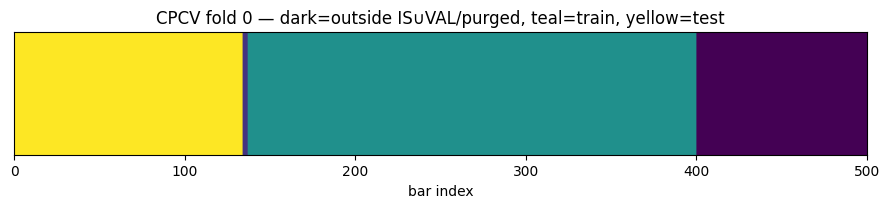

In [6]:
# Visualise one fold: notice the purged/embargoed GAP (white) between train and test.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 1.6))
lane = np.full(T, 0.0)
lane[split.is_val_mask] = 0.3                 # eligible domain
lane[f0.train] = 1.0                          # train
lane[f0.test] = 2.0                           # test
ax.imshow(lane.reshape(1, -1), aspect="auto", cmap="viridis",
          extent=[0, T, 0, 1])
ax.set_yticks([]); ax.set_xlabel("bar index")
ax.set_title("CPCV fold 0 — dark=outside IS∪VAL/purged, teal=train, yellow=test")
plt.show()

### 1c · Walk-forward folds (`splits.walk_forward_folds`)

CPCV is the fast *development* engine. For the **thesis results chapter** the whole
loop is re-run period-by-period inside a walk-forward wrapper (anchored/expanding by
default), so every discovery is OOS to the *next* period. Same purge+embargo seam.

In [6]:
from quant_fund_agent.research_eval.splits import walk_forward_folds

wf = walk_forward_folds(CLOSE.index, n_folds=4, horizon=6, embargo=3, anchored=True)
for f in wf:
    tr = np.flatnonzero(f.train); te = np.flatnonzero(f.test)
    print(f"fold {f.fold}: train {tr[0]:>3}..{tr[-1]:>3} ({tr.size} bars)  "
          f"→ test {te[0]:>3}..{te[-1]:>3} ({te.size} bars)")

fold 0: train   0.. 73 (74 bars)  → test  80..159 (80 bars)
fold 1: train   0..153 (154 bars)  → test 160..239 (80 bars)
fold 2: train   0..233 (234 bars)  → test 240..319 (80 bars)
fold 3: train   0..313 (314 bars)  → test 320..399 (80 bars)


### 1d · Deflation — billing the search for every look (`research_eval/deflation.py`)

Under the null, the *maximum* of many noisy IC estimates is large purely by luck
(≈ `sqrt(2·ln N_trials)` for `N_trials` candidates). The controller counts every
evaluated candidate as a trial and these helpers inflate the significance bar:

- `deflated_ic` — haircut the best `|IC|` / its t-stat for `N_trials`. `deflated_t > 0`
  is the hard gate: the edge must beat *selection luck*.
- `deflated_sharpe_ratio` — Bailey–López de Prado DSR.
- `pbo_cscv` — **Probability of Backtest Overfitting** (a headline thesis metric):
  fraction of CSCV splits where the in-sample winner lands in the OOS bottom half.

In [7]:
from quant_fund_agent.research_eval.deflation import deflated_ic, deflated_sharpe_ratio, pbo_cscv

# The SAME observed IC survives 5 trials but is killed by 5000 trials:
for nt in (5, 500, 5000):
    d = deflated_ic(best_abs_ic=0.05, n_obs=4000, n_trials=nt)
    print(f"N_trials={nt:>5}: luck_ic={d['luck_ic']:.4f}  "
          f"deflated_ic={d['deflated_ic']:.4f}  deflated_t={d['deflated_t']:+.3f}  "
          f"→ gate {'PASS' if d['deflated_t'] > 0 else 'FAIL'}")

# PBO on synthetic performance: pure noise ⇒ ~0.5 (coin-flip = maximally overfit-prone).
noise = np.random.default_rng(0).normal(size=(240, 10))
print("\nPBO(pure noise, 10 candidates) =", round(pbo_cscv(noise, n_groups=10)["pbo"], 3))

N_trials=    5: luck_ic=0.0284  deflated_ic=0.0216  deflated_t=+1.368  → gate PASS
N_trials=  500: luck_ic=0.0557  deflated_ic=0.0000  deflated_t=-0.363  → gate FAIL
N_trials= 5000: luck_ic=0.0653  deflated_ic=0.0000  deflated_t=-0.965  → gate FAIL

PBO(pure noise, 10 candidates) = 0.222


## 2 · The fitness function — `research_eval/harness.py` (the *reward* channel)

`evaluate_candidate(...)` is the un-gameable reward. It takes **signals** (never
LLM text), and returns a `FitnessResult` with three parts:

1. `objective` — the **CORE Pareto vector**, four axes, all *maximised*
   (`fitness.ObjectiveVector`):
   1. `marginal_value` *(primary)* — LOCO ΔOOS-IC: how much the combined model's
      VAL IC rises when you **add** this factor to the book. This is why a
      low-standalone-IC volatility factor can still score well — it measures
      *conditional* value, not standalone power.
   2. `independence` — Δ participation ratio (effective # independent factors) minus
      a soft `max|corr|` penalty.
   3. `robustness` — `mean_cpcv(IC) − λ·std_cpcv(IC) − plateau_penalty + sign_bonus`.
   4. `parsimony` — `−complexity` (operators + constants from the AST).
2. `gates` — hard booleans (`coverage`, `degradation`, `deflation`). A candidate
   that fails any gate is treated as **dominated** (`GateResults`).
3. `diagnostics` — the rich dict handed to Reflection / the LLM (the teacher channel).

Let's score a candidate against an **empty book** first (so marginal value = its
own edge).

In [8]:
from quant_fund_agent.comparison.config import ComparisonConfig
from quant_fund_agent.research_eval.harness import evaluate_candidate, EvalParams

cfg = ComparisonConfig(preruns=["evo"], target_horizon=6)

strong = make_signal(strength=1.5, seed=11)      # lots of edge
weak   = make_signal(strength=0.02, seed=12)     # basically noise

CODE_2OPS = "signal = ts_mean(close, 20) - ts_mean(close, 5)"  # feeds the parsimony axis

def score(sig, book=(), n_trials=50, code=CODE_2OPS, expected_sign=1):
    return evaluate_candidate(sig, list(book), PANEL, cfg,
                              params=EvalParams(n_trials=n_trials),
                              candidate_code=code, expected_sign=expected_sign)

r_strong = score(strong)
r_weak   = score(weak)
print("STRONG  objective:", {k: (round(v,3) if v is not None else None)
                              for k,v in r_strong.objective.to_dict().items()})
print("STRONG  gates    :", r_strong.gates.to_dict())
print("WEAK    objective:", {k: (round(v,3) if v is not None else None)
                             for k,v in r_weak.objective.to_dict().items()})
print("WEAK    gates    :", r_weak.gates.to_dict(), "  <-- fails a gate ⇒ dominated")

STRONG  objective: {'marginal_value': 0.382, 'independence': 1.0, 'robustness': 0.35, 'parsimony': -5.0}
STRONG  gates    : {'coverage_ok': True, 'degradation_ok': True, 'deflation_ok': True, 'cost_ok': None, 'passed': True}
WEAK    objective: {'marginal_value': -0.049, 'independence': 1.0, 'robustness': 0.013, 'parsimony': -5.0}
WEAK    gates    : {'coverage_ok': True, 'degradation_ok': None, 'deflation_ok': False, 'cost_ok': None, 'passed': False, 'reasons': {'deflation': 'deflated_t=-1.295493 ≤ 0 (N_trials=50)'}}   <-- fails a gate ⇒ dominated


#### Marginal value (LOCO) — the heart of the reward

Now put a factor in the **book** and evaluate a *near-duplicate* of it vs a
*complementary* one. A redundant factor adds little marginal ΔIC and correlates
highly with the book; an independent one adds edge the book lacks.

In [9]:
book_factor = make_signal(strength=1.2, w=6, seed=20)          # already "in the book"
near_dup    = book_factor + np.random.default_rng(21).normal(0, 0.01, (T, N))  # ~same signal
complement  = make_signal(strength=1.0, w=25, seed=22)         # different mechanism/horizon

for label, sig in [("near-duplicate", near_dup), ("complement", complement)]:
    r = score(sig, book=[book_factor])
    d = r.diagnostics
    print(f"{label:>14}:  marginal ΔIC={r.objective.marginal_value:+.4f}  "
          f"max|corr| to book={d['max_abs_corr']:.2f}  "
          f"Δparticipation={d['delta_participation']:+.2f}  "
          f"independence={r.objective.independence:+.3f}")

near-duplicate:  marginal ΔIC=-0.0001  max|corr| to book=0.98  Δparticipation=+0.02  independence=-0.477
    complement:  marginal ΔIC=-0.0088  max|corr| to book=0.07  Δparticipation=+0.99  independence=+0.953


#### The plateau penalty (parameter sensitivity)

Robustness docks a candidate whose VAL IC **collapses under a ±10% window jitter** —
overfit factors are knife-edge spikes; real ones sit on plateaus. The harness takes
`jitter_signals` (the signals of window-jittered variants); the evolution loop
produces them automatically via the jitter operator (§3). Here we hand-fake a
"knife-edge" variant (edge halves) vs a "plateau" variant (edge unchanged).

In [10]:
base_sig    = make_signal(strength=1.2, seed=30)
plateau_var = make_signal(strength=1.15, seed=31)      # jitter barely changes it → plateau
knife_var   = make_signal(strength=0.2,  seed=32)      # jitter guts it → knife-edge

r_plateau = evaluate_candidate(base_sig, [], PANEL, cfg, params=EvalParams(n_trials=50),
                               candidate_code=CODE_2OPS, expected_sign=1,
                               jitter_signals=[plateau_var, plateau_var])
r_knife   = evaluate_candidate(base_sig, [], PANEL, cfg, params=EvalParams(n_trials=50),
                               candidate_code=CODE_2OPS, expected_sign=1,
                               jitter_signals=[knife_var, knife_var])
print("plateau variant → penalty",
      round(r_plateau.diagnostics['plateau_penalty'], 4),
      "| robustness", round(r_plateau.objective.robustness, 4))
print("knife   variant → penalty",
      round(r_knife.diagnostics['plateau_penalty'], 4),
      "| robustness", round(r_knife.objective.robustness, 4), " <-- docked")

plateau variant → penalty 0.0 | robustness 0.2771
knife   variant → penalty 0.2352 | robustness 0.0419  <-- docked


#### The shared primitives

Two numeric helpers in `fitness.py` are reused everywhere (so the harness and the
`comparison/` analytics track can't drift): `participation_ratio` (effective # of
independent factors from a correlation matrix) and `complexity` (AST operator +
constant count → the parsimony axis).

In [11]:
from quant_fund_agent.research_eval.fitness import participation_ratio, complexity

ortho = np.eye(4)                       # 4 perfectly independent factors
allsame = np.ones((4, 4))               # 4 identical factors
print("participation ratio: orthogonal 4 →", round(participation_ratio(ortho), 2),
      "| identical 4 →", round(participation_ratio(allsame), 2))
print("complexity('a*b + c - 3') =", complexity("a*b + c - 3"))
print("complexity of a gnarly factor >> a lean one — that's the parsimony pressure")

participation ratio: orthogonal 4 → 4.0 | identical 4 → 1.0
complexity('a*b + c - 3') = 4
complexity of a gnarly factor >> a lean one — that's the parsimony pressure


#### SET mode (`evaluate_set`) — the AlphaEvolve-style unit

In SET mode the genome is a whole "alpha program" (a list of factors scored
*jointly*). The axes change meaning: axis 1 is the set's **own** combined-model OOS
IC (no external book), axis 2 is the set's *internal* participation ratio normalised
by size. Same helpers, so the two modes can't drift.

In [12]:
from quant_fund_agent.research_eval.harness import evaluate_set

members = {
    "m_fast": make_signal(strength=1.2, w=5,  seed=40),
    "m_slow": make_signal(strength=1.0, w=25, seed=41),
    "m_mid":  make_signal(strength=0.8, w=12, seed=42),
}
rset = evaluate_set(members, PANEL, cfg, params=EvalParams(n_trials=50),
                    member_codes={k: CODE_2OPS for k in members})
print("SET objective:", {k: (round(v,3) if v is not None else None)
                         for k,v in rset.objective.to_dict().items()})
print("combined VAL IC :", round(rset.diagnostics['combined_val_ic'], 4))
print("internal PR     :", round(rset.diagnostics['internal_participation_ratio'], 3),
      "of", rset.diagnostics['set_size'], "members")

SET objective: {'marginal_value': 0.388, 'independence': 0.991, 'robustness': 0.304, 'parsimony': -5.0}
combined VAL IC : 0.3884
internal PR     : 2.974 of 3 members


## 3 · The genome & mutation operators — `evolution/genome.py`, `mutation.py`

### The genome

`FactorProgram` = source code + the hypothesis metadata the LLM declared (notably
`expected_sign`, the falsifiable direction claim that powers the sign-consistency
check). `Genome` wraps one program (SINGLE) or several (SET) plus **lineage**
(parents, operator, generation, island). `code_fingerprint()` is the dedup key: it
masks the factor id and normalises whitespace, so an LLM re-emitting the same
program under a new id is still caught as a duplicate (and doesn't waste an
`N_trials` billing).

In [9]:
from quant_fund_agent.agents.factor_research.evolution.genome import FactorProgram, Genome

FACTOR_CODE = '''
from quant_fund_agent.factors.base import BaseFactor
from quant_fund_agent.factors.registry import register_factor
from quant_fund_agent.factors.ops import ts_mean, delta
@register_factor
class MomFactor(BaseFactor):
    factor_id = "mom_20"
    inputs = ["close"]
    prediction_horizon = 6
    def calc(self, data):
        c = data["close"]
        return delta(c, 5) / ts_mean(c, 20)
'''
p = FactorProgram(factor_id="mom_20", code=FACTOR_CODE, name="momentum", expected_sign=1)
g = Genome(genome_id="g0-mom", programs=[p], operator="seed")
print("SINGLE genome factor ids:", g.factor_ids)
print("fingerprint            :", g.code_fingerprint())

# same code, different id + indentation ⇒ SAME fingerprint (dedup is robust)
p2 = FactorProgram(factor_id="mom_20_copy",
                   code=FACTOR_CODE.replace("mom_20", "mom_20_copy").replace("        c", "         c"),
                   name="dup")
print("re-emitted-as-new-id fp:", Genome("g0-dup", [p2]).code_fingerprint(),
      "→ dedup catches it" if Genome("g0-dup",[p2]).code_fingerprint()==g.code_fingerprint() else "")

SINGLE genome factor ids: ['mom_20']
fingerprint            : 3bd744933e52b619
re-emitted-as-new-id fp: 3bd744933e52b619 → dedup catches it


### Operator 1 — programmatic window-jitter (deterministic, no LLM)

An AST transform scales the integer *window* constants a factor passes to the
time-series ops (`ts_mean(x, 20)` → `ts_mean(x, 22)`). It plays **two** roles:

- a cheap **mutation operator** (`random_jitter_child`), and
- the **plateau probe** from §2 (`jitter_variants` builds the ±10% variants whose
  VAL IC the harness compares against the candidate's).

In [10]:
from quant_fund_agent.agents.factor_research.evolution import mutation as mut

print("window constants found:", mut.window_constants(FACTOR_CODE))       # [5, 20]

up, n = mut.jitter_windows(FACTOR_CODE, 1.1)
print(f"jitter ×1.1 changed {n} windows →", mut.window_constants(up))       # [6, 22]

# the plateau-probe variants (used as jitter_signals in §2), each with a unique id:
for pid, pcode in mut.jitter_variants(p, scales=(0.9, 1.1)):
    print(f"  probe {pid}: windows {mut.window_constants(pcode)}")

# the jitter MUTATION operator: each window scaled by U(1-pct, 1+pct)
child = mut.random_jitter_child(p, np.random.default_rng(0), new_id="mom_20_j", pct=0.10)
print("jitter child:", child.factor_id, "windows", mut.window_constants(child.code),
      "| same hypothesis, new windows")

window constants found: [5, 20]
jitter ×1.1 changed 2 windows → [6, 22]
  probe mom_20_jit0: windows [4, 18]
  probe mom_20_jit1: windows [6, 22]
jitter child: mom_20_j windows [6, 19] | same hypothesis, new windows


### Operator 2 — LLM-semantic mutation / crossover (the creative one)

The LLM is shown **one parent** (mutation) or **two** (crossover), each *with its
deterministic reflection brief* (§4), and asked for an improved child in one call —
FunSearch-style. The LLM proposes; it never scores. Below we just **build the prompt**
(no API call) so you can read what the model actually sees. Note it embeds the
data-scope context, the operator reference, the parent code, the reflection brief,
and a strict JSON output schema.

In [12]:
from quant_fund_agent.agents.factor_research.evolution.mutation import (
    build_mutation_prompt, build_crossover_prompt, parse_child_response)

DATA_CONTEXT = ("DATA CONTEXT\n------------\nPrice/volume fields:\n"
                "    close: last trade price per bar\n    volume: shares traded\n")
BRIEF = "VERDICT: passed every hard gate.\nMarginal value (primary axis): +0.012 ...\n(the §4 reflection brief goes here)"

prompt = build_mutation_prompt(p, brief=BRIEF, data_context=DATA_CONTEXT,
                               existing_ids=["mom_20", "vol_10"])
print(prompt[:1200])
print("\n... [prompt continues: STRICT REQUIREMENTS + JSON schema] ...")

You are a senior quantitative researcher running an evolutionary search over
alpha-factor programs.  Below is a PARENT factor and the deterministic
evaluation report our research harness produced for it.  Your task is to
propose ONE improved CHILD factor: keep what works, fix what the report
criticises, and state a falsifiable hypothesis for the child.

Think like a scientist, not a curve-fitter: the child must embody an economic
mechanism, not just perturbed constants.  If the report shows the parent is
redundant with the book, change the *mechanism*, not the window.  If the edge
decays instantly, look for a slower expression of the same idea (or declare a
shorter horizon).  If the parent failed gates badly, it is fine to propose a
substantially different factor inspired by the parent's weaknesses.

DATA CONTEXT
------------
DATA CONTEXT
------------
Price/volume fields:
    close: last trade price per bar
    volume: shares traded


OPERATOR REFERENCE
------------------
The factor co

In [13]:
# OPTIONAL: actually call the LLM to mutate the parent (needs OPENAI_API_KEY).
RUN_LIVE_LLM = True
if RUN_LIVE_LLM:
    from quant_fund_agent.llm import make_chat_llm
    llm = make_chat_llm(temperature=0.6, timeout=120, max_retries=2)
    resp = llm.invoke(prompt)
    child = parse_child_response(getattr(resp, "content", str(resp)))
    print("LLM child id:", child.factor_id, "| horizon", child.prediction_horizon,
          "| sign", child.expected_sign)
    print(child.trading_idea)
else:
    print("RUN_LIVE_LLM is False — skipping the real LLM call. "
          "parse_child_response() would turn its JSON into a FactorProgram.")

LLM child id: mom_25 | horizon 6 | sign 1
This factor aims to capture momentum by evaluating the recent price changes in relation to a longer-term average. By incorporating a lagged average, the model seeks to mitigate noise and improve the robustness of the signal, providing a clearer indication of persistent price trends.


## 4 · Reflection — `evolution/reflection.py` (the *teacher* channel)

`mutation_brief(fitness)` renders a `FitnessResult`'s **diagnostics** into the
natural-language brief the mutating LLM reads. It is written **deterministically**
(no LLM writes it) so it can never drift into flattery or self-reinforcement, and it
only ever quotes OOS statistics — the LLM sees *how* a candidate failed, never the
data it failed on. It even emits **targeted, rule-based advice** ("83%-correlated
with a book factor — change the mechanism, not the constants").

We build a deliberately-flawed `FitnessResult` by hand to trigger the advice rules.

In [14]:
from quant_fund_agent.research_eval.fitness import ObjectiveVector, GateResults, FitnessResult
from quant_fund_agent.agents.factor_research.evolution.reflection import mutation_brief

flawed = FitnessResult(
    candidate_id="cand_bad",
    objective=ObjectiveVector(marginal_value=0.001, independence=-0.4,
                              robustness=-0.02, parsimony=-14),
    gates=GateResults(coverage_ok=True, degradation_ok=False, deflation_ok=True,
                      reasons={"degradation": "OOS/IS=0.20 < τ=0.5"}),
    diagnostics=dict(
        standalone_ic=0.002, is_ic=0.06, val_ic=0.012, val_n_obs=800,
        residual_ic=0.001, with_ic=0.031, base_ic=0.030,
        max_abs_corr=0.83, delta_participation=-0.1, pr_before=3.0, pr_after=2.9,
        cpcv_ic_mean=0.004, cpcv_ic_std=0.03, cpcv_n_folds=15,
        sign_consistency=False, plateau_penalty=0.05, jitter_ics=[0.001, -0.002],
        coverage=0.62, degradation_ratio=0.20, complexity=14, n_trials=120,
        ic_decay={"1": 0.002, "3": 0.004, "6": 0.012, "12": 0.030, "24": 0.021},
        deflation={"deflated_t": 0.4, "luck_ic": 0.02}))

print(mutation_brief(flawed, book_size=5))

VERDICT: FAILED hard gate(s) — degradation: OOS/IS=0.20 < τ=0.5.
Marginal value (primary axis): adding this factor moved the combined model's OOS IC by +0.0010 (with=+0.0310, book-only=+0.0300, book size=5).
Standalone IC at the target horizon: +0.0020 (IS=+0.0600, VAL=+0.0120); residual IC after regressing out the book: +0.0010.
IC decay across horizons: 1b=+0.0020, 3b=+0.0040, 6b=+0.0120, 12b=+0.0300, 24b=+0.0210.  |IC| peaks at 12 bars (+0.0300).
Independence: Δ participation ratio -0.1000 (book effective factors +3.00 → +2.90); max |corr| to an existing factor: +0.8300.
Robustness: CPCV IC mean +0.0040 ± +0.0300 over 15 purged folds; OOS/IS degradation ratio +0.2000.
Parameter sensitivity: jittering the window constants ±10% moved the VAL IC to ['+0.0010', '-0.0020'] — plateau penalty +0.0500.
Hypothesis sign check: declared direction CONTRADICTED by the realized IC sign.
Complexity (operators + constants): 14.
Multiple-testing deflation: after 120 trials the deflated IC t-stat is 

Read the `WHAT TO DO DIFFERENTLY` block: every line is triggered by a numeric rule
(high `max|corr|` → "change the mechanism"; `degradation_ratio < 0.5` → "classic
overfit, simplify"; `sign_consistency is False` → "direction contradicts your
hypothesis"; the IC-decay peak at horizon 12 → "re-anchor `prediction_horizon`").
That is the teacher channel steering the next generation — with **numbers only**.

## 5 · The evolution controller — `evolution/controller.py` (deterministic NSGA-II)

The **selection** half. It only ever consumes `FitnessResult` objects (numbers +
gate booleans) — never a word of LLM output — so the LLM can't touch its own reward.

- **Constrained dominance** (Deb 2002): a gate-passing candidate always beats a
  gate-failing one; two failers compare by *how many* gates they fail; only then do
  Pareto objectives decide.
- **Non-dominated sort** into fronts + **crowding distance** for within-front spread.
- **Archive** = the gate-passing non-dominated front over everything ever evaluated.
  Per the locked design decision, *the archive **is** the accepted book* against which
  SINGLE-mode marginal value is scored.
- **Islands** + ring **migration**, **N_trials** billing, full **lineage**.

In [15]:
from quant_fund_agent.agents.factor_research.evolution.controller import (
    non_dominated_sort, constrained_dominates, crowding_distance)

def mkfit(cid, mv, indep, rob, par, gates_ok=True):
    return FitnessResult(cid, ObjectiveVector(mv, indep, rob, par),
                         GateResults(coverage_ok=gates_ok, degradation_ok=gates_ok,
                                     deflation_ok=gates_ok))
pop = [
    mkfit("A", 0.10, 0.5, 0.20, -3),           # front 0 (high marginal)
    mkfit("B", 0.05, 0.9, 0.30, -2),           # front 0 (very independent + parsimonious)
    mkfit("C", 0.08, 0.4, 0.10, -5),           # dominated by A
    mkfit("D", 0.20, 0.9, 0.40, -1, gates_ok=False),  # great numbers but FAILS gates
]
fronts = non_dominated_sort(pop)
print("fronts (indices):", fronts, "  → D is last despite the best vector (gate fail)")
print("A dominates C? ", constrained_dominates(pop[0], pop[2]))
print("A dominates B? ", constrained_dominates(pop[0], pop[1]), "(they're a trade-off)")
print("crowding (front 0):", {["A","B","C","D"][i]: crowding_distance(pop, fronts[0])[i]
                              for i in fronts[0]})

fronts (indices): [[0, 1], [2], [3]]   → D is last despite the best vector (gate fail)
A dominates C?  True
A dominates B?  False (they're a trade-off)
crowding (front 0): {'A': inf, 'B': inf}


### Watch the archive form as genomes are inserted

We insert five evaluated genomes and watch the Pareto archive (the accepted book)
keep only the non-dominated, gate-passing ones. Then draw two parents by tournament.

In [16]:
from quant_fund_agent.agents.factor_research.evolution.controller import (
    EvolutionController, ControllerConfig, EvaluatedGenome)

ctrl = EvolutionController(ControllerConfig(population_size=8, seed=0))
demo = [("A", 0.10, 0.5, 0.20, -3, True),
        ("B", 0.05, 0.9, 0.30, -2, True),
        ("C", 0.08, 0.4, 0.10, -5, True),      # dominated by A → won't be in archive
        ("D", 0.20, 0.9, 0.40, -1, False),     # gate fail → never enters archive
        ("E", 0.12, 0.6, 0.25, -2, True)]      # enters, may evict A
for cid, mv, ind, rob, par, ok in demo:
    ctrl.next_trial()
    fit = mkfit(cid, mv, ind, rob, par, gates_ok=ok)
    gnome = Genome(f"g0-{cid}", [FactorProgram(cid, FACTOR_CODE, name=cid)], operator="seed")
    ctrl.insert(EvaluatedGenome(gnome, fit))
    print(f"after {cid}: archive =", sorted(eg.genome.factor_ids[0] for eg in ctrl.archive))

print("\nN_trials billed:", ctrl.n_trials, "| lineage rows:", len(ctrl.lineage))
parents = ctrl.select_parents(2)
print("tournament parents:", [pp.genome.factor_ids[0] for pp in parents])

after A: archive = ['A']
after B: archive = ['A', 'B']
after C: archive = ['A', 'B']
after D: archive = ['A', 'B']
after E: archive = ['B', 'E']

N_trials billed: 5 | lineage rows: 5
tournament parents: ['E', 'B']


## 6 · RAG retrieval — `knowledge/embed_store.py`, `retrieval.py`

Idea sourcing, grounded in the paper library. Two embedding granularities
(whole-paper for routing, chunks for grounding/citation checks), cosine retrieval,
**date-gating** (undated papers are excluded under a cutoff — no look-ahead), and
**citation verification** (a `source_paper_id` the LLM cites but that wasn't
retrieved is a hallucination and is dropped).

We use a tiny synthetic corpus + the offline `hash` embedder (set in §0) so this
runs with no key. In a real run `EmbedStore()` loads the ~1k-paper library and the
`openai` embedder.

In [20]:
from quant_fund_agent.knowledge.embed_store import EmbedStore, CorpusDoc, verify_citations

corpus = [
    CorpusDoc("p1", "Cross-sectional momentum in equity returns", "2015-01-01",
              "Past winners keep winning over medium horizons; trading volume confirms trends."),
    CorpusDoc("p2", "Order-flow imbalance and short-term price impact", "2018-06-01",
              "Order-flow imbalance in the limit order book predicts short-term returns via inventory risk."),
    CorpusDoc("p3", "Post-earnings announcement drift", "2012-03-01",
              "Prices underreact to earnings surprises; the drift continues for weeks (PEAD)."),
]
# cache_dir → a throwaway temp dir so this synthetic corpus never pollutes the
# real data/knowledge/embeddings/ (a real run uses the default on-disk cache).
import tempfile
store = EmbedStore(corpus, embedder="hash",
                   cache_dir=tempfile.mkdtemp(prefix="qf_nb_embed_")).build()

hits = store.retrieve_papers("limit order book flow imbalance short horizon",
                             k=2, cutoff_date="2020-01-01")
print("query → top papers:", [(h.paper_id, round(h.score, 3)) for h in hits])

# date-gating: a 2016 cutoff excludes the 2018 order-flow paper
gated = store.retrieve_papers("microstructure order flow", k=3, cutoff_date="2016-01-01")
print("with cutoff 2016-01-01, allowed:", [h.paper_id for h in gated], "(p2 is hidden)")

# citation verification
ok, bad = verify_citations(claimed_ids=["p2", "p_hallucinated"], retrieved_ids=["p1", "p2"])
print("verified citations:", ok, "| dropped hallucinations:", bad)

query → top papers: [('p2', 0.642), ('p1', 0.0)]
with cutoff 2016-01-01, allowed: ['p1', 'p3'] (p2 is hidden)
verified citations: ['p2'] | dropped hallucinations: ['p_hallucinated']


### Cardinality modes (`retrieval.retrieve_and_brainstorm`)

- **`1toN`** — each retrieved paper grounds its own brainstorm call (idea provenance
  = that one paper).
- **`Nto1`** — N papers in **one** call, and each idea must *synthesise* mechanisms
  across ≥2 of them (where genuinely novel factors come from).
- **`NtoM`** — N papers, M ideas, no synthesis constraint.

`retrieve_and_brainstorm(...)` needs an LLM to write the ideas, so it's gated. The
query construction (`build_query`) is offline — it favours papers whose mechanisms
are *computable from the run's fields*.

In [21]:
from quant_fund_agent.knowledge.retrieval import build_query, retrieve_and_brainstorm

q = build_query(data_context=DATA_CONTEXT, focus="microstructure liquidity provision",
                gaps=["order flow imbalance pressure"])
print("constructed retrieval query:\n", q)

if RUN_LIVE_LLM:
    from quant_fund_agent.llm import make_chat_llm
    ideas = retrieve_and_brainstorm(
        make_chat_llm(temperature=0.7), store, n_ideas=3, known_ids=set(),
        data_context=DATA_CONTEXT, cardinality="Nto1", k_papers=3, cutoff_date="2020-01-01")
    for i in ideas:
        print("-", i.get("factor_id"), "| grounded in", i.get("source_paper_ids"))
else:
    print("\nRUN_LIVE_LLM is False — real brainstorm skipped.")

constructed retrieval query:
 quantitative trading alpha factor cross-sectional return prediction
microstructure liquidity provision
underexplored mechanisms: order flow imbalance pressure
computable from fields: close, volume

RUN_LIVE_LLM is False — real brainstorm skipped.


## 7 · GraphRAG — the custom hybrid graph

The novelty: **fuse an LLM-extracted *semantic* graph with a *computed
quantitative* graph** in one NetworkX store (`knowledge/graph_store.py`).

- **Semantic layer** (LLM-extracted, `graph_build.py`): `Paper —proposes→ Mechanism`,
  `Mechanism —realized_by→ Factor`, `Mechanism —needs→ Field`, `related_to`, `documents`.
- **Empirical layer** (computed each generation, `empirical_edges.py`):
  `Factor —corr→ Factor` (signal correlation), `Factor —uses→ Field`, plus per-mechanism
  coverage stats.

The build pass makes one structured LLM call per paper; here we **simulate the
extraction payloads by hand** (so it's offline) and fold them in with the real
`ingest_paper`.

In [22]:
from quant_fund_agent.knowledge.graph_store import KnowledgeGraph
from quant_fund_agent.knowledge import graph_build, graph_query, empirical_edges

FIELDS = ["close", "volume", "orderFlow", "epsSurprise"]   # the run's usable fields
g = KnowledgeGraph()

# each dict is what the LLM extraction returns for a paper (mechanisms + field needs)
graph_build.ingest_paper(g, corpus[0], {"mechanisms": [
    {"name": "cross-sectional momentum", "description": "winners keep winning",
     "required_fields": ["close", "volume"], "anomaly": "momentum"}]}, FIELDS)
graph_build.ingest_paper(g, corpus[1], {"mechanisms": [
    {"name": "order flow imbalance pressure", "description": "OFI predicts returns",
     "required_fields": ["orderFlow"], "anomaly": None}]}, FIELDS)
graph_build.ingest_paper(g, corpus[2], {"mechanisms": [
    {"name": "post earnings drift", "description": "underreaction to earnings surprises",
     "required_fields": ["epsSurprise"], "anomaly": "PEAD"}]}, FIELDS)

print("graph:", g.summary())
graph_build.detect_and_summarize_communities(g)   # Louvain (Leiden if installed)
print("communities:", {c: [n.split(':')[-1] for n in m]
                       for c, m in g.community_members().items()})

graph: {'paper': 3, 'mechanism': 3, 'field': 4, 'anomaly': 2, 'edges': 9}
communities: {1: ['p1', 'cross_sectional_momentum', 'momentum'], 2: ['p2', 'order_flow_imbalance_pressure'], 0: ['p3', 'post_earnings_drift', 'pead']}


### The empirical layer + provenance link-back

When a factor is born from a mechanism-grounded idea, `link_factor_to_mechanism`
closes the `Paper → Mechanism → Factor → Field` provenance path. `refresh_*` recompute
the derived edges/coverage from live signals & declared inputs.

In [23]:
# a factor realises ONLY the momentum mechanism → the other two mechanisms are "gaps"
empirical_edges.link_factor_to_mechanism(g, "mom_20", "cross-sectional momentum")
empirical_edges.refresh_field_usage(g, {"mom_20": ["close", "volume"]})
empirical_edges.refresh_mechanism_coverage(g, {"mom_20": 0.03})

# factor↔factor correlation edges from live signals (the fusion that makes it hybrid)
sigs = {"mom_20": make_signal(1.2, seed=50), "mom_dup": make_signal(1.2, seed=50)}
n_edges = empirical_edges.refresh_factor_correlations(g, sigs, threshold=0.3)
print("correlation edges written:", n_edges, "(the two near-identical signals get linked)")

correlation edges written: 1 (the two near-identical signals get linked)


### Gap-finding queries (`graph_query.py`) — *where should the search look next?*

This is what steers `--retrieval graphrag`. Note how `computable_unexploited` drops
the earnings-drift gap because it needs `epsSurprise`, which is **out of the run's
field scope** — "novel AND computable" is the combination worth an island.

In [24]:
print("mechanism gaps (papers but no factor):",
      [m.split(':')[-1] for m in graph_query.mechanism_gaps(g)])

scope = ["close", "volume", "orderFlow"]     # NOTE: no epsSurprise
print("computable & unexploited (given scope):",
      [m.split(':')[-1] for m in graph_query.computable_unexploited(g, scope)],
      "  ← earnings-drift is dropped (needs epsSurprise)")

print("\nper-island focus strings (mechanism-level diversity for islands):")
for i, f in enumerate(graph_query.island_focus(g, n_islands=2, available_fields=scope)):
    print(f"  island {i}: {f[:90]}")

print("\nlocal grounding bundle for one mechanism:")
lc = graph_query.local_context(g, "order flow imbalance pressure")
print("  ", {k: lc[k] for k in ("mechanism", "papers", "factors", "needed_fields")})

mechanism gaps (papers but no factor): ['order_flow_imbalance_pressure', 'post_earnings_drift']
computable & unexploited (given scope): ['order_flow_imbalance_pressure']   ← earnings-drift is dropped (needs epsSurprise)

per-island focus strings (mechanism-level diversity for islands):
  island 0: Community 0: 1 mechanism(s) (post earnings drift) across 1 paper(s).
  island 1: Community 2: 1 mechanism(s) (order flow imbalance pressure) across 1 paper(s). target mech

local grounding bundle for one mechanism:
   {'mechanism': 'order flow imbalance pressure', 'papers': [{'paper_id': 'p2', 'title': 'Order-flow imbalance and short-term price impact', 'published_date': '2018-06-01'}], 'factors': [], 'needed_fields': ['orderFlow']}


Building the **real** graph over the paper library is a one-off LLM pass:

```bash
./venv/bin/python scripts/build_knowledge_graph.py        # add --limit N to smoke-test
```

It writes `data/knowledge/graph.json`; `--retrieval graphrag` then loads it to steer
seeding toward computable gap mechanisms and to seed each island on a different
community.

## 8 · The closed loop, wired together — `evolution/loop.py`

Now assemble it. One **generation** = today's linear pipeline generalised:

```
seed  →  (select parent(s) → mutate/crossover/jitter → compile in-memory →
          evaluate deterministically → insert into controller)  ×  children_per_gen
       →  migrate elites (every k gens, if >1 island)  →  checkpoint
```

- **Seeding** (`seed_programs`) reuses the existing brainstorm/codegen path (optionally
  RAG/GraphRAG-grounded), so `oneshot` and `evolution` start from the same generator.
- **Operators** are chosen per child by seeded RNG from `{llm_semantic, crossover,
  jitter}` (SET mode: `{structural, splice, member_jitter}`).
- **Evaluation** compiles candidates **in-memory** (never touching files/registry) and
  scores via the MCP seam (`research_client.evaluate_fitness`; identical in-process
  under `QF_USE_MCP=0`). The plateau jitter-probes ride along in the same call.
- **Book** = the controller's Pareto **archive** (evolves as the run progresses).
- **Persistence**: every generation checkpoints `state.json` + `lineage.jsonl`; at the
  end `persist_archive` materialises survivors into real factor files with full
  `metadata.evolution` provenance, so downstream harnesses consume an evolution prerun
  exactly like a oneshot one.

The `EvolutionRunConfig` is the one place all the knobs live:

In [25]:
from quant_fund_agent.agents.factor_research.evolution.loop import EvolutionRunConfig
import dataclasses
for f in dataclasses.fields(EvolutionRunConfig):
    print(f"  {f.name:24} = {getattr(EvolutionRunConfig(), f.name)!r}")

  generations              = 5
  population_size          = 10
  children_per_generation  = 8
  n_islands                = 1
  migration_every          = 5
  seed                     = 0
  unit                     = 'single'
  set_size                 = 3
  p_llm_semantic           = 0.6
  p_crossover              = 0.25
  p_jitter                 = 0.15
  n_seed_ideas             = 8
  seed_papers              = 0
  retrieval                = 'none'
  retrieval_cardinality    = '1toN'
  rag_k                    = 4
  debate                   = 'off'
  target_horizon           = 6
  is_frac                  = 0.6
  val_frac                 = 0.2
  cpcv_groups              = 6
  cpcv_k                   = 2
  embargo                  = 0
  plateau_scales           = (0.9, 1.1)
  cutoff_date              = None
  data_dir                 = 'ticker_data'
  n_tickers                = 15
  out_dir                  = 'data/evolution'


### A fully-offline "mini loop" that actually turns

The real `EvolutionLoop` needs an LLM (mutation) + the MCP panel (evaluation). To
watch the closed loop *turn* with zero dependencies, we wire the **real** components
— `EvolutionController`, the real `evaluate_candidate` harness, the real
`random_jitter_child` operator, the real `mutation_brief` — on our synthetic panel,
using **jitter-only** mutation (so no LLM). This is exactly the loop structure of
`loop.py`, just with the LLM operator swapped out.

In [26]:
import uuid
from quant_fund_agent.agents.factor_research.evolution.reflection import mutation_brief

def factor_code(fid: str, w: int) -> str:
    return (f'from quant_fund_agent.factors.base import BaseFactor\n'
            f'from quant_fund_agent.factors.registry import register_factor\n'
            f'from quant_fund_agent.factors.ops import ts_mean\n'
            f'@register_factor\n'
            f'class F(BaseFactor):\n'
            f'    factor_id = "{fid}"\n    inputs = ["close"]\n    prediction_horizon = 6\n'
            f'    def calc(self, data): return ts_mean(data["close"], {w})')

loop_ctrl = EvolutionController(ControllerConfig(population_size=6, seed=1))
sig_cache: dict[str, pd.DataFrame] = {}
briefs: dict[str, str] = {}

def make_prog(fid, w):
    return FactorProgram(factor_id=fid, code=factor_code(fid, w), name=fid, expected_sign=1)

def evaluate_and_insert(prog, strength, w, *, generation, operator, parents=()):
    # signal edge is a function of the (jittered) window here — a stand-in for "the
    # factor's real behaviour" so jittering windows genuinely changes fitness.
    sig_cache[prog.factor_id] = make_signal(strength, w, seed=abs(hash(prog.factor_id)) % 9999)
    book = [sig_cache[eg.genome.program.factor_id] for eg in loop_ctrl.archive
            if eg.genome.program.factor_id != prog.factor_id]
    n = loop_ctrl.next_trial()
    fit = evaluate_candidate(sig_cache[prog.factor_id], book, PANEL, cfg,
                             params=EvalParams(n_trials=n), candidate_code=prog.code,
                             expected_sign=1, candidate_id=prog.factor_id)
    gnome = Genome(f"g{generation}-{prog.factor_id}-{uuid.uuid4().hex[:4]}", [prog],
                   generation=generation, operator=operator,
                   parent_ids=[p.genome.genome_id for p in parents])
    if loop_ctrl.is_duplicate(gnome):
        return None
    loop_ctrl.insert(EvaluatedGenome(gnome, fit))
    briefs[gnome.genome_id] = mutation_brief(fit, book_size=len(loop_ctrl.archive))
    return fit

# ── generation 0: seed three factors of decreasing edge ──
for fid, strength, w in [("seed_fast", 1.5, 5), ("seed_slow", 0.6, 20), ("seed_noise", 0.05, 10)]:
    evaluate_and_insert(make_prog(fid, w), strength, w, generation=0, operator="seed")
print(f"gen0: archive={sorted(eg.genome.factor_ids[0] for eg in loop_ctrl.archive)} "
      f"n_trials={loop_ctrl.n_trials}")

# ── generations 1..4: pick a parent by tournament, jitter its window, re-evaluate ──
for gen in range(1, 5):
    for _ in range(3):                       # children_per_generation = 3
        par = loop_ctrl.select_parents(1)[0]
        new_id = f"{par.genome.program.factor_id}_g{gen}_{uuid.uuid4().hex[:3]}"
        child = mut.random_jitter_child(par.genome.program, loop_ctrl.rng, new_id)
        if child is None:
            continue
        w = mut.window_constants(child.code)[0]
        # inherit ~parent edge with a small random perturbation (a jitter can help or hurt)
        strength = 1.2 * float(loop_ctrl.rng.uniform(0.8, 1.15))
        evaluate_and_insert(child, strength, w, generation=gen, operator="jitter", parents=[par])
    print(f"gen{gen}: archive={sorted(eg.genome.factor_ids[0] for eg in loop_ctrl.archive)} "
          f"n_trials={loop_ctrl.n_trials}")

print("\nFinal archive (the 'accepted book'):")
for eg in loop_ctrl.archive:
    o = eg.fitness.objective
    print(f"  {eg.genome.factor_ids[0]:24} gen{eg.genome.generation} "
          f"op={eg.genome.operator:7} marginal={o.marginal_value:+.4f} "
          f"robust={o.robustness:+.4f}")

gen0: archive=['seed_fast'] n_trials=3


gen1: archive=['seed_fast'] n_trials=6


gen2: archive=['seed_fast'] n_trials=9


gen3: archive=['seed_fast'] n_trials=12


gen4: archive=['seed_fast'] n_trials=15

Final archive (the 'accepted book'):
  seed_fast                gen0 op=seed    marginal=+0.3942 robust=+0.3705


That is the whole machine in miniature: parents are drawn by NSGA-II tournament, a
deterministic operator proposes a child, the **deterministic harness** scores it OOS,
`N_trials` is billed, and the Pareto archive keeps only what genuinely dominates. Swap
`random_jitter_child` for the LLM mutation operator + the reflection brief, and swap the
synthetic panel for the MCP-served real panel, and you have `loop.py` exactly.

### Lineage — the audit trail for the thesis

Every insertion appends a lineage row (who mutated from whom, under which operator,
the objective vector, gates, `N_trials` at eval). `loop.py` writes these to
`lineage.jsonl` each generation.

In [27]:
import json
print("last 3 lineage rows:")
for row in loop_ctrl.lineage[-3:]:
    print(json.dumps({k: row[k] for k in
                      ("genome_id", "operator", "parent_ids", "generation", "selectable")},
                     default=str))

last 3 lineage rows:
{"genome_id": "g4-seed_slow_g1_e7d_g3_39c_g4_d72-3096", "operator": "jitter", "parent_ids": ["g3-seed_slow_g1_e7d_g3_39c-71ce"], "generation": 4, "selectable": true}
{"genome_id": "g4-seed_noise_g4_091-d8d2", "operator": "jitter", "parent_ids": ["g0-seed_noise-21b5"], "generation": 4, "selectable": true}
{"genome_id": "g4-seed_noise_g4_49d-22c9", "operator": "jitter", "parent_ids": ["g0-seed_noise-21b5"], "generation": 4, "selectable": true}


## 9 · Running the real thing — the ablation matrix

The notebook above dissected every part offline. To run the *actual* system (real
LLM ideation, real market panel), use the CLI. Each run is a self-contained **prerun**
under `data/workspaces/<config>/preruns/<name>/`, so the comparison/rolling harnesses
score them directly.

```bash
# 0) (once) build the knowledge graph for the GraphRAG arm
./venv/bin/python scripts/build_knowledge_graph.py

# 1) baseline: one-shot (today's researcher)
./venv/bin/python run_factor_research.py --name oneshot --dedup-scope prerun

# 2) + evolution (no RAG/debate) — does closed-loop Pareto search beat one-shot?
./venv/bin/python run_factor_evolution.py --name evo --generations 8 --population 12

# 3) + RAG                — does retrieval-grounded ideation help?
./venv/bin/python run_factor_evolution.py --name evo_rag --retrieval rag --retrieval-cardinality Nto1

# 4) + GraphRAG           — does structured gap-finding beat flat RAG?
./venv/bin/python run_factor_evolution.py --name evo_graph --retrieval graphrag --islands 2

# 5) + debate             — does adversarial critique raise OOS quality?
./venv/bin/python run_factor_evolution.py --name evo_debate --retrieval graphrag --debate on

# single vs set
./venv/bin/python run_factor_evolution.py --name evo_set --evolution-unit set --set-size 3

# final touch-once validation: re-run the WHOLE loop per fold, score OOS on the next period
./venv/bin/python run_factor_evolution.py --name evo --walk-forward 2021-01-01,2022-01-01,2023-01-01
```

A tiny **smoke run** (fast, in-process, a handful of tickers) to confirm the plumbing
end-to-end on your machine:

```bash
QF_USE_MCP=0 ./venv/bin/python run_factor_evolution.py --name evosmoke --reset \
    --generations 2 --population 4 --children-per-gen 3 --seed-ideas 4 --n-tickers 8
```

Headline metrics are reported **OOS only**: combined-model OOS IC/Sharpe, PBO,
deflated Sharpe (N_trials-aware), effective # independent factors, turnover. Live
status: `docs/research-evolution/IMPLEMENTATION_PROGRESS.md`.

---

### Recap — where each idea lives

| You saw… | in… |
| --- | --- |
| IS/VAL/TEST, CPCV purge+embargo, walk-forward | `research_eval/splits.py` |
| N_trials deflation, DSR, PBO | `research_eval/deflation.py` |
| the 4-axis Pareto vector + hard gates | `research_eval/fitness.py` |
| the deterministic reward harness | `research_eval/harness.py` |
| genome + fingerprint dedup | `evolution/genome.py` |
| jitter + LLM mutation/crossover prompts | `evolution/mutation.py` |
| numbers → NL mutation brief | `evolution/reflection.py` |
| constrained NSGA-II + archive + islands + N_trials | `evolution/controller.py` |
| whole-paper/chunk embeddings, date-gating, citations | `knowledge/embed_store.py` |
| cardinality modes 1toN/Nto1/NtoM | `knowledge/retrieval.py` |
| the hybrid semantic+empirical graph | `knowledge/graph_store.py`, `empirical_edges.py` |
| LLM extraction + communities | `knowledge/graph_build.py` |
| gap-finding + island focus | `knowledge/graph_query.py` |
| seed → select → mutate → evaluate → insert | `evolution/loop.py` |
| the CLI entrypoint + ablation arms | `run_factor_evolution.py` |

## 10 · New capabilities (WS1–WS5)

Everything above was the original system. This section demos the additions, still
fully offline:

- **WS1** — deflation moved off the per-candidate gate to a shared **publish filter**
  (`research_eval/publish.py`), applied *once* at selection on the combined book.
- **WS3** — economic reward folded in (a **turnover/cost gate** + a **perturbation**
  robustness probe), **no new axis**.
- **WS2** — a **Quality-Diversity** behavior grid (`--selection qd`) that fills a
  *diverse* library while keeping the same 5-axis Pareto as per-cell quality.
- **WS5** — a per-config **experience memory** (survivors + negative evidence).

In [ ]:
# ── WS1: deflation is now a shared PUBLISH filter (selection-time, not a per-candidate gate) ──
from quant_fund_agent.research_eval.publish import publish_filter
from quant_fund_agent.research_eval.splits import three_way_split

split = three_way_split(PANEL["close"].index)
book = {"strong": make_signal(1.5, seed=1),      # real edge, high marginal
        "weak":   make_signal(0.02, seed=2),     # ~noise, ~0 marginal (a parasite)
        "medium": make_signal(0.5, seed=3)}

for mode in ("off", "on"):                        # off = discovery, on = validation
    res = publish_filter(book, PANEL["close"], cfg, split, n_trials=200, mode=mode)
    print(f"selection-deflation={mode:3}: kept={res['kept_factor_ids']} "
          f"passed={res['passed']} dropped={res['dropped']}")

# ── WS3: economic reward — turnover/cost gate + perturbation-fidelity probe (folded in, no new axis) ──
sig = make_signal(1.2, seed=5)
base = evaluate_candidate(sig, [], PANEL, cfg, params=EvalParams())                 # baseline arm
econ = evaluate_candidate(sig, [], PANEL, cfg,
                          params=EvalParams(gate_turnover=0.3, perturbation_weight=2.0))
print("\nbaseline  turnover=", round(base.diagnostics['turnover'], 3),
      "robustness=", round(base.objective.robustness, 4), "cost_ok=", base.gates.cost_ok)
print("econ-on   turnover=", round(econ.diagnostics['turnover'], 3),
      "robustness=", round(econ.objective.robustness, 4), "cost_ok=", econ.gates.cost_ok,
      "perturbation_penalty=", econ.diagnostics['perturbation_penalty'])
print("(axis count unchanged:", len(base.objective.AXES), "axes)")

In [ ]:
# ── WS2: Quality-Diversity behavior grid — fills a DIVERSE library, not a single front ──
from quant_fund_agent.agents.factor_research.evolution.controller import (
    EvolutionController, ControllerConfig, EvaluatedGenome)
from quant_fund_agent.agents.factor_research.evolution.genome import Genome, FactorProgram

qd = EvolutionController(ControllerConfig(selection="qd", grid_dims=2, seed=0))
for i, w in enumerate([3, 10, 20, 40, 60]):          # different windows → different behavior cells
    s = make_signal(1.2, w, seed=100 + i)
    fit = evaluate_candidate(s, [], PANEL, cfg, params=EvalParams(n_trials=i + 1),
                             candidate_code=f"signal = ts_mean(close, {w})", candidate_id=f"f{i}")
    g = Genome(f"g0-f{i}", [FactorProgram(f"f{i}", "x = 1", name=f"f{i}")], operator="seed")
    qd.insert(EvaluatedGenome(g, fit))
print("QD grid occupancy (trend_reversal × signal_speed):", qd.qd.occupancy())
print("cells filled:", qd.qd.n_cells(),
      "| accepted book (union of cell elites):", sorted(fid for fid, _ in qd.archive_programs()))

# ── WS5: cross-run experience memory — survivors AND controlled negative evidence ──
from quant_fund_agent.knowledge.graph_store import KnowledgeGraph
from quant_fund_agent.knowledge import experience

mem = KnowledgeGraph()
for _ in range(6):                                  # a mechanism tried a lot, never survives
    experience.record_attempt(mem, "crowded_momentum", survived=False, generation=1)
for _ in range(4):                                  # a healthy one
    experience.record_attempt(mem, "vol_state", survived=True, marginal=0.02, generation=1)
experience.record_survivor(mem, "vol_1", val_ic=0.03, marginal_value=0.02, mechanism_name="vol_state")
print("\nexhausted (steer next run away):", experience.exhausted_mechanisms(mem))
print("teacher summary:", experience.memory_summary(mem))